In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/diabetes.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"{col}: {zeros} zeros ({pct:.1f}%)")

Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


In [5]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()

for col in cols_to_fix:
    median_val = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print("Zeros remaining after cleaning:")
for col in cols_to_fix:
    print(f"{col}: {(df_clean[col] == 0).sum()}")

Zeros remaining after cleaning:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [6]:
print("Before Cleaning - Insulin Stats:")
print(df['Insulin'].describe())

print("\nAfter Cleaning - Insulin Stats:")
print(df_clean['Insulin'].describe())

Before Cleaning - Insulin Stats:
count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

After Cleaning - Insulin Stats:
count    768.000000
mean     140.671875
std       86.383060
min       14.000000
25%      121.500000
50%      125.000000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64


In [7]:
print("Null Values:")
print(df_clean.isnull().sum())

print("\nDataset Shape:", df_clean.shape)

print("\nColumn Names:")
print(df_clean.columns.tolist())

print("\nData Types:")
print(df_clean.dtypes)

Null Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [8]:
df_clean.to_csv('../data/diabetes_clean.csv', index=False)
print("Cleaned dataset saved successfully!")

PermissionError: [Errno 13] Permission denied: '../data/diabetes_clean.csv'

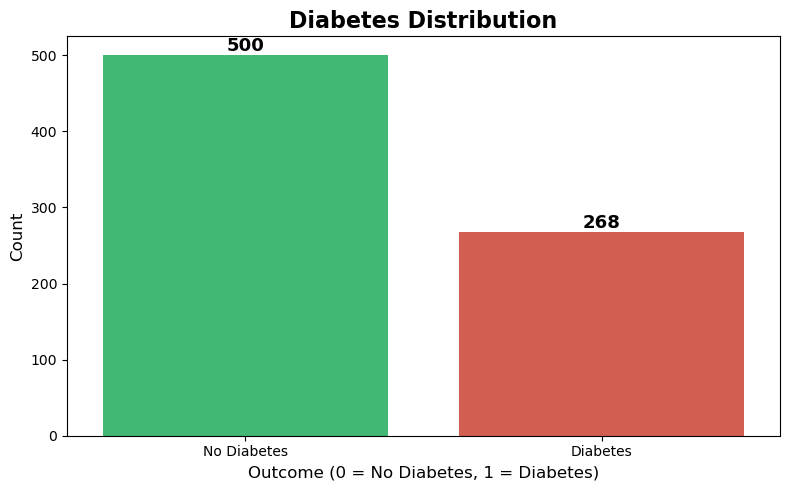

In [9]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(x='Outcome', data=df_clean, 
                   palette=['#2ECC71', '#E74C3C'])

plt.title('Diabetes Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/01_disease_count.png', dpi=150)
plt.show()

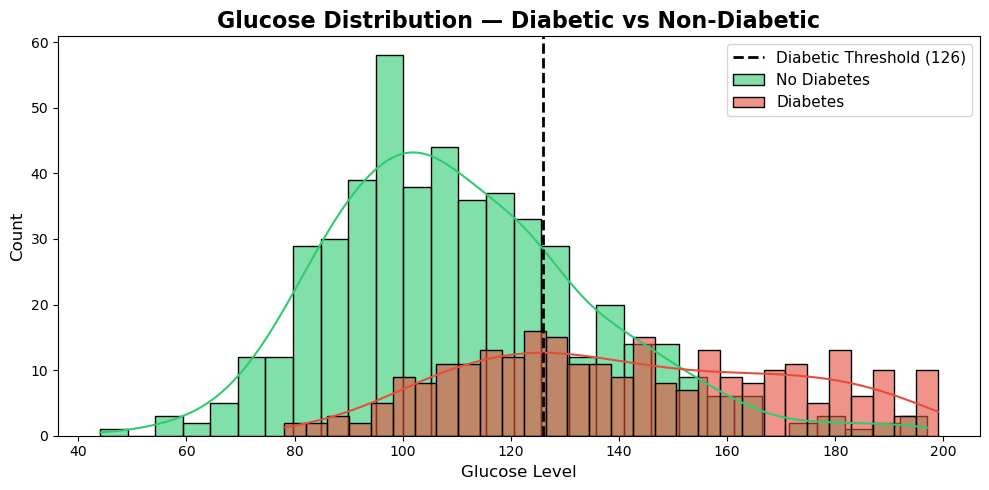

In [10]:
plt.figure(figsize=(10, 5))

no_diabetes = df_clean[df_clean['Outcome'] == 0]
diabetes = df_clean[df_clean['Outcome'] == 1]

sns.histplot(no_diabetes['Glucose'], bins=30, kde=True, 
             color='#2ECC71', label='No Diabetes', alpha=0.6)
sns.histplot(diabetes['Glucose'], bins=30, kde=True, 
             color='#E74C3C', label='Diabetes', alpha=0.6)

plt.axvline(126, color='black', linestyle='--', linewidth=2, 
            label='Diabetic Threshold (126)')

plt.title('Glucose Distribution — Diabetic vs Non-Diabetic', 
          fontsize=16, fontweight='bold')
plt.xlabel('Glucose Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/02_glucose_distribution.png', dpi=150)
plt.show()

In [11]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Insulin', 'Age', 'DiabetesPedigreeFunction']

print("=" * 65)
print(f"{'Feature':<28} {'No Diabetes':>15} {'Diabetes':>15}")
print("=" * 65)

for feature in features:
    no_diab_mean = df_clean[df_clean['Outcome']==0][feature].mean()
    diab_mean = df_clean[df_clean['Outcome']==1][feature].mean()
    print(f"{feature:<28} {no_diab_mean:>15.2f} {diab_mean:>15.2f}")

print("=" * 65)
print(f"{'Total Patients':<28} {(df_clean['Outcome']==0).sum():>15} {(df_clean['Outcome']==1).sum():>15}")

Feature                          No Diabetes        Diabetes
Pregnancies                             3.30            4.87
Glucose                               110.68          142.13
BloodPressure                          70.92           75.12
BMI                                    30.89           35.38
Insulin                               127.79          164.70
Age                                    31.19           37.07
DiabetesPedigreeFunction                0.43            0.55
Total Patients                           500             268


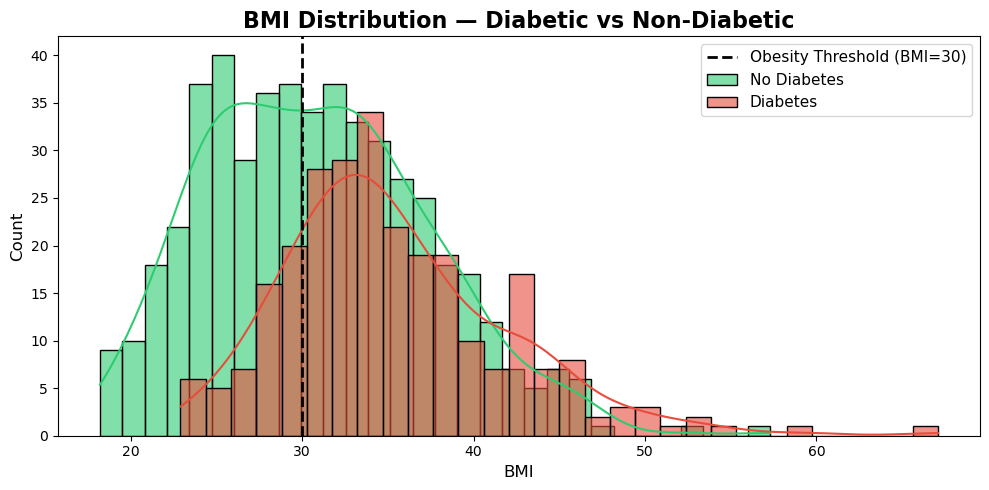

In [12]:
plt.figure(figsize=(10, 5))

no_diabetes = df_clean[df_clean['Outcome'] == 0]
diabetes = df_clean[df_clean['Outcome'] == 1]

sns.histplot(no_diabetes['BMI'], bins=30, kde=True,
             color='#2ECC71', label='No Diabetes', alpha=0.6)
sns.histplot(diabetes['BMI'], bins=30, kde=True,
             color='#E74C3C', label='Diabetes', alpha=0.6)

plt.axvline(30, color='black', linestyle='--', linewidth=2,
            label='Obesity Threshold (BMI=30)')

plt.title('BMI Distribution — Diabetic vs Non-Diabetic',
          fontsize=16, fontweight='bold')
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/03_bmi_distribution.png', dpi=150)
plt.show()

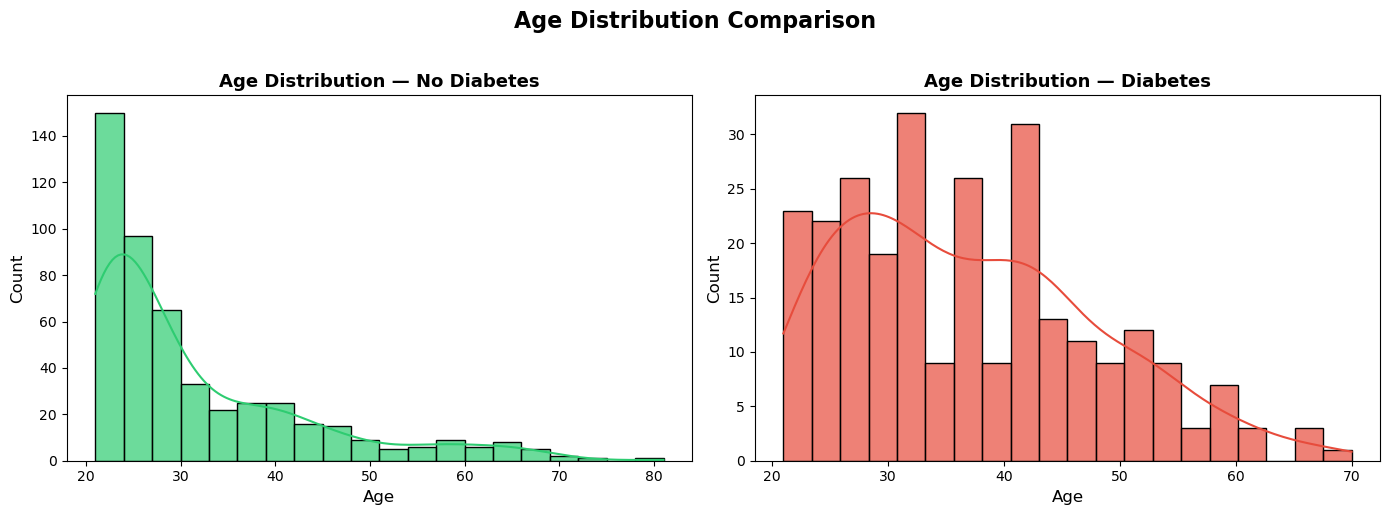

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

no_diabetes = df_clean[df_clean['Outcome'] == 0]
diabetes = df_clean[df_clean['Outcome'] == 1]

# No Diabetes
sns.histplot(no_diabetes['Age'], bins=20, kde=True,
             color='#2ECC71', alpha=0.7, ax=axes[0])
axes[0].set_title('Age Distribution — No Diabetes',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Diabetes
sns.histplot(diabetes['Age'], bins=20, kde=True,
             color='#E74C3C', alpha=0.7, ax=axes[1])
axes[1].set_title('Age Distribution — Diabetes',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.suptitle('Age Distribution Comparison', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../plots/04_age_distribution.png', dpi=150)
plt.show()

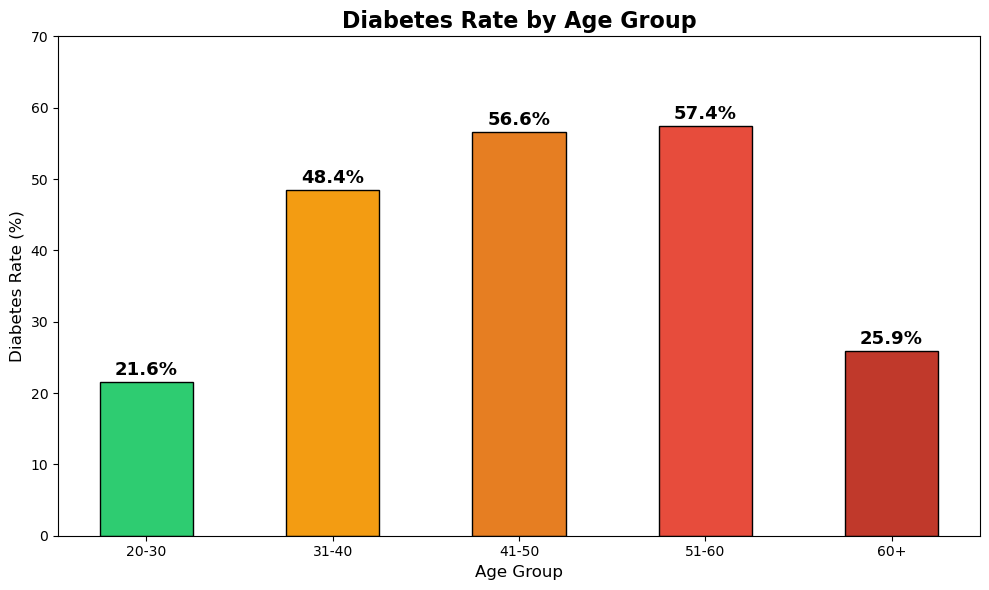

In [13]:
# Create age groups
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], 
                               bins=[20, 30, 40, 50, 60, 100],
                               labels=['20-30', '31-40', '41-50', '51-60', '60+'])

# Calculate diabetes rate per age group
age_group = df_clean.groupby('AgeGroup')['Outcome'].mean() * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(age_group.index, age_group.values, 
               color=['#2ECC71', '#F39C12', '#E67E22', '#E74C3C', '#C0392B'],
               edgecolor='black', width=0.5)

# Add percentage labels on top of bars
for bar, val in zip(bars, age_group.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center', 
             fontsize=13, fontweight='bold')

plt.title('Diabetes Rate by Age Group', 
          fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Diabetes Rate (%)', fontsize=12)
plt.ylim(0, 70)

plt.tight_layout()
plt.savefig('../plots/04_age_distribution.png', dpi=150)
plt.show()

In [14]:
print(df_clean.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'AgeGroup']


In [15]:
df_clean = df_clean.drop(columns=['AgeGroup'])
print(df_clean.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


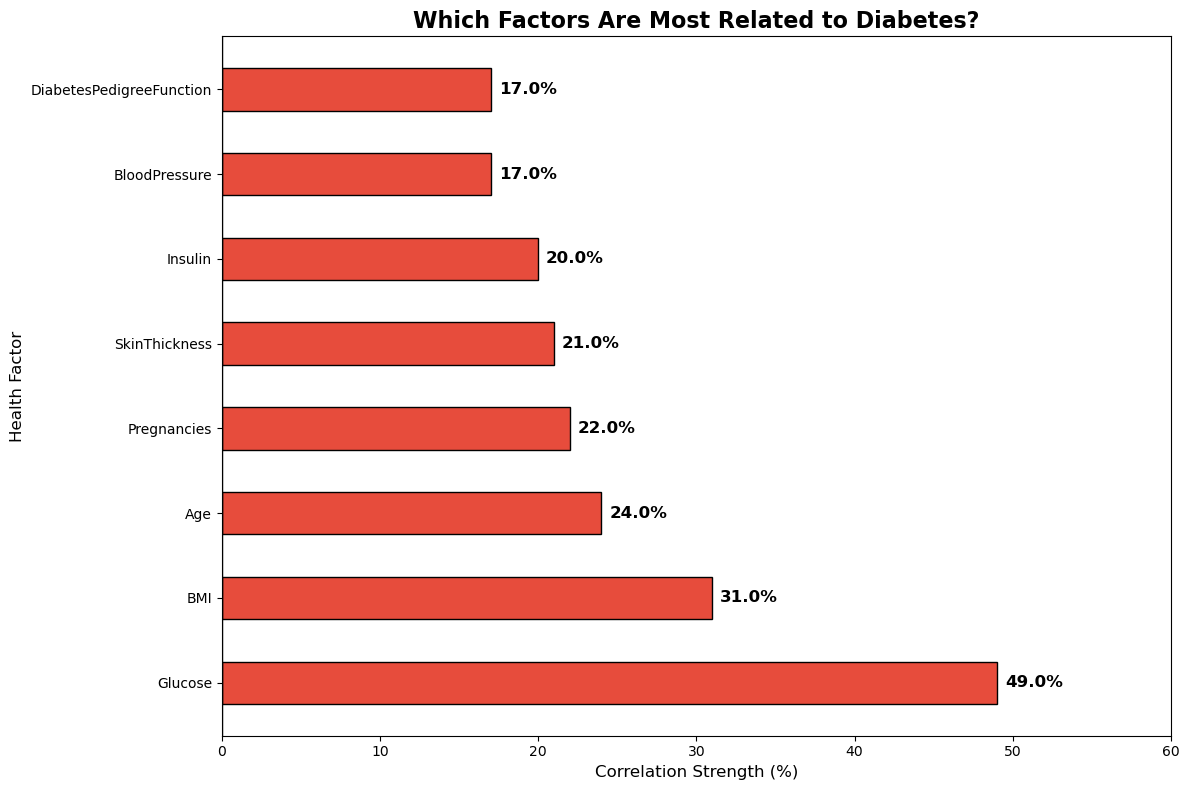

In [16]:
plt.figure(figsize=(12, 8))

corr = df_clean.corr().round(2)

outcome_corr = corr['Outcome'].drop('Outcome').sort_values(ascending=False)

# Convert to percentage
outcome_pct = outcome_corr * 100

colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in outcome_pct.values]

bars = plt.barh(outcome_pct.index, outcome_pct.values,
                color=colors, edgecolor='black', height=0.5)

for bar, val in zip(bars, outcome_pct.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=12, fontweight='bold')

plt.axvline(0, color='black', linewidth=1)
plt.title('Which Factors Are Most Related to Diabetes?',
          fontsize=16, fontweight='bold')
plt.xlabel('Correlation Strength (%)', fontsize=12)
plt.ylabel('Health Factor', fontsize=12)
plt.xlim(0, 60)

plt.tight_layout()
plt.savefig('../plots/05_correlation.png', dpi=150)
plt.show()

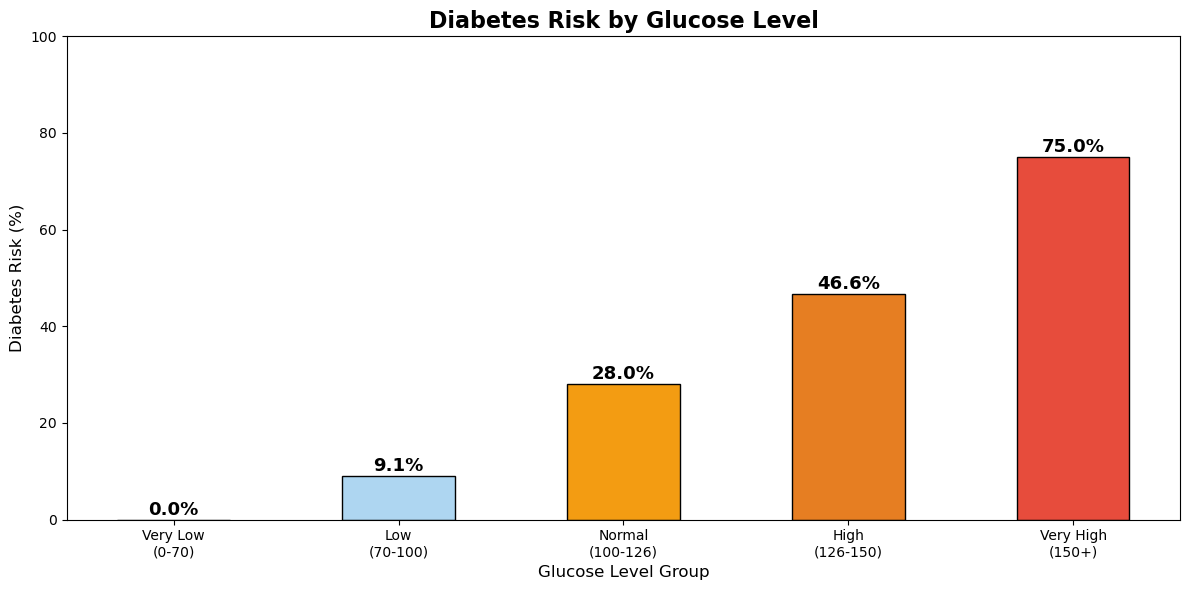

In [8]:
df_clean = pd.read_csv('../data/diabetes_clean.csv')

df_clean['GlucoseGroup'] = pd.cut(df_clean['Glucose'],
                                   bins=[0, 70, 100, 126, 150, 200],
                                   labels=['Very Low\n(0-70)', 
                                           'Low\n(70-100)',
                                           'Normal\n(100-126)', 
                                           'High\n(126-150)',
                                           'Very High\n(150+)'])

glucose_group = df_clean.groupby('GlucoseGroup')['Outcome'].mean() * 100

plt.figure(figsize=(12, 6))
colors = ['#2ECC71', '#AED6F1', '#F39C12', '#E67E22', '#E74C3C']
bars = plt.bar(glucose_group.index, glucose_group.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, glucose_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Diabetes Risk by Glucose Level',
          fontsize=16, fontweight='bold')
plt.xlabel('Glucose Level Group', fontsize=12)
plt.ylabel('Diabetes Risk (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('../plots/diabetes_glucose_risk.png', dpi=150)
plt.show()

df_clean = df_clean.drop(columns=['GlucoseGroup'])

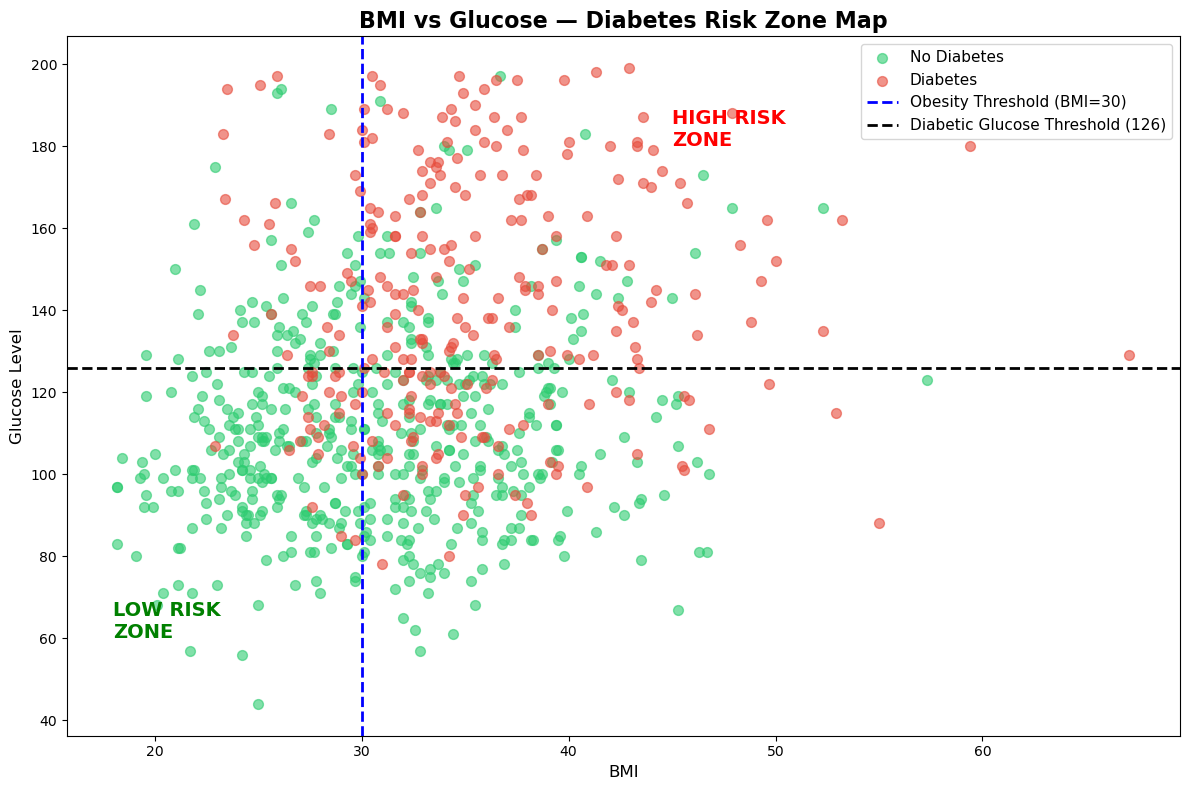

In [32]:
plt.figure(figsize=(12, 8))

# Plot non-diabetic patients
no_diabetes = df_clean[df_clean['Outcome'] == 0]
diabetes = df_clean[df_clean['Outcome'] == 1]

plt.scatter(no_diabetes['BMI'], no_diabetes['Glucose'],
            color='#2ECC71', alpha=0.6, label='No Diabetes', s=50)
plt.scatter(diabetes['BMI'], diabetes['Glucose'],
            color='#E74C3C', alpha=0.6, label='Diabetes', s=50)

# Threshold lines
plt.axvline(30, color='blue', linestyle='--', 
            linewidth=2, label='Obesity Threshold (BMI=30)')
plt.axhline(126, color='black', linestyle='--', 
            linewidth=2, label='Diabetic Glucose Threshold (126)')

# Zone labels
plt.text(45, 180, 'HIGH RISK\nZONE', fontsize=14, 
         color='red', fontweight='bold')
plt.text(18, 60, 'LOW RISK\nZONE', fontsize=14, 
         color='green', fontweight='bold')

plt.title('BMI vs Glucose — Diabetes Risk Zone Map',
          fontsize=16, fontweight='bold')
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Glucose Level', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/06_risk_zone.png', dpi=150)
plt.show()

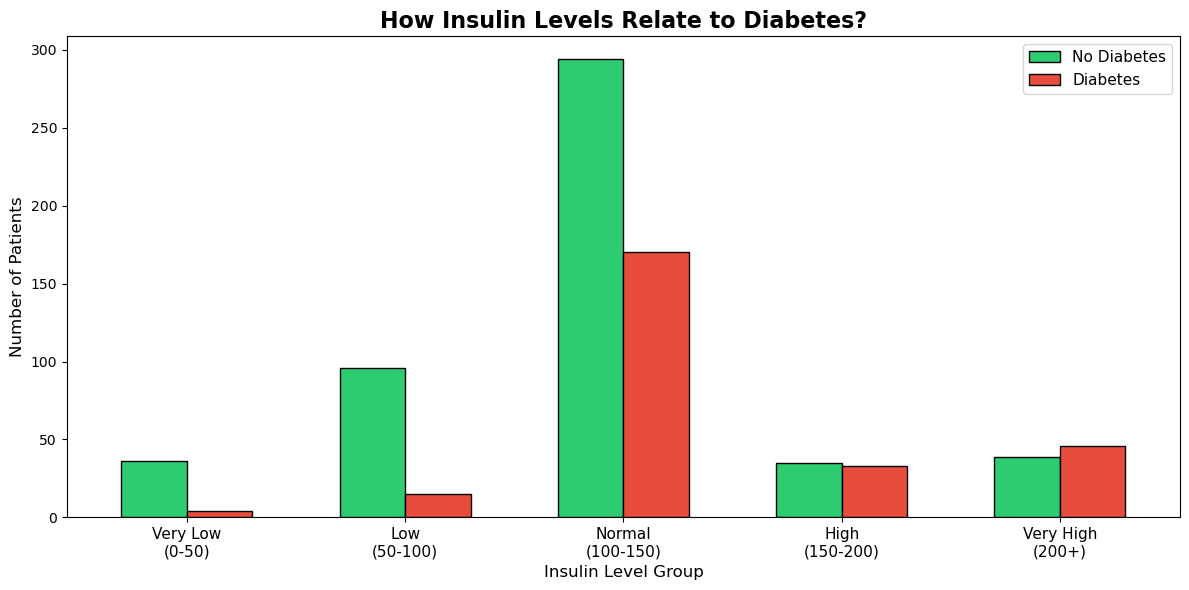

In [38]:
# Calculate averages
no_diab_avg = df_clean[df_clean['Outcome']==0]['Insulin'].median()
diab_avg = df_clean[df_clean['Outcome']==1]['Insulin'].median()

# Create age groups for insulin
df_clean['InsulinGroup'] = pd.cut(df_clean['Insulin'],
                                   bins=[0, 50, 100, 150, 200, 900],
                                   labels=['Very Low\n(0-50)', 'Low\n(50-100)', 
                                           'Normal\n(100-150)', 'High\n(150-200)', 
                                           'Very High\n(200+)'])

insulin_group = df_clean.groupby(['InsulinGroup', 'Outcome']).size().unstack()
insulin_group.columns = ['No Diabetes', 'Diabetes']

insulin_group.plot(kind='bar', figsize=(12, 6),
                   color=['#2ECC71', '#E74C3C'],
                   edgecolor='black', width=0.6)

plt.title('How Insulin Levels Relate to Diabetes?',
          fontsize=16, fontweight='bold')
plt.xlabel('Insulin Level Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/08_insulin_distribution.png', dpi=150)
plt.show()

df_clean = df_clean.drop(columns=['InsulinGroup'])

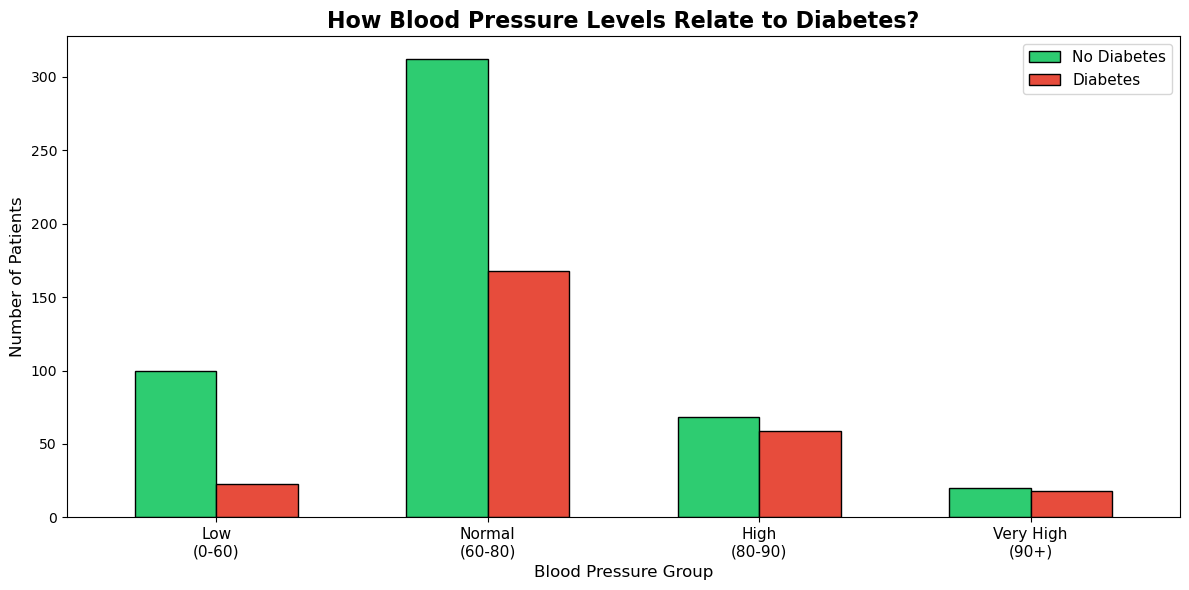

In [39]:
# Create BloodPressure groups
df_clean['BPGroup'] = pd.cut(df_clean['BloodPressure'],
                              bins=[0, 60, 80, 90, 122],
                              labels=['Low\n(0-60)', 'Normal\n(60-80)', 
                                      'High\n(80-90)', 'Very High\n(90+)'])

bp_group = df_clean.groupby(['BPGroup', 'Outcome']).size().unstack()
bp_group.columns = ['No Diabetes', 'Diabetes']

bp_group.plot(kind='bar', figsize=(12, 6),
              color=['#2ECC71', '#E74C3C'],
              edgecolor='black', width=0.6)

plt.title('How Blood Pressure Levels Relate to Diabetes?',
          fontsize=16, fontweight='bold')
plt.xlabel('Blood Pressure Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/09_bp_distribution.png', dpi=150)
plt.show()

df_clean = df_clean.drop(columns=['BPGroup'])

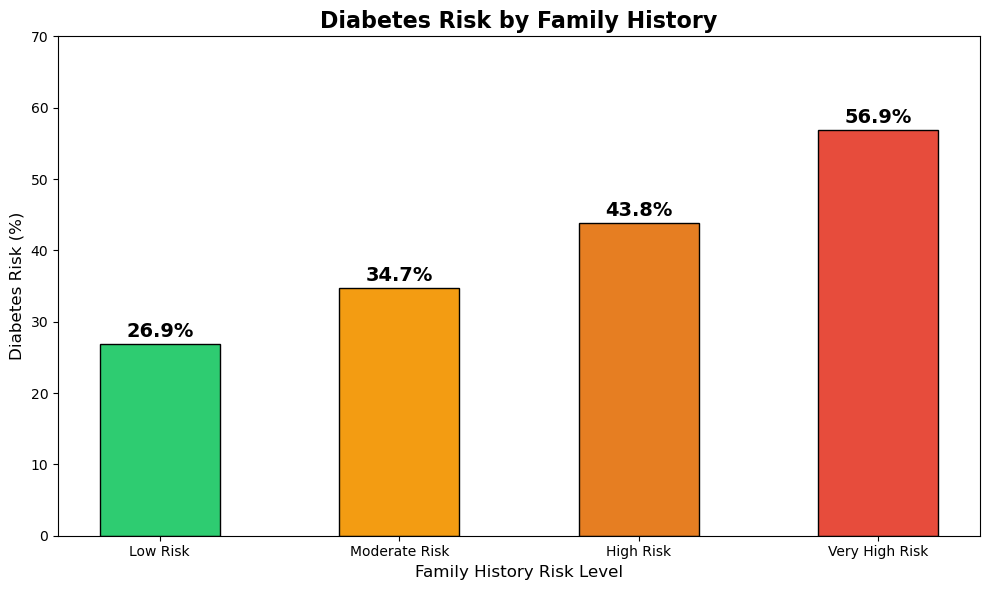

In [46]:
df_clean['DPFGroup'] = pd.cut(df_clean['DiabetesPedigreeFunction'],
                               bins=[0, 0.3, 0.6, 1.0, 2.5],
                               labels=['Low Risk', 'Moderate Risk', 
                                       'High Risk', 'Very High Risk'])

dpf_rate = df_clean.groupby('DPFGroup')['Outcome'].mean() * 100

plt.figure(figsize=(10, 6))

colors = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C']
bars = plt.bar(dpf_rate.index, dpf_rate.values,
               color=colors, edgecolor='black', width=0.5)

# Add percentage on top of each bar
for bar, val in zip(bars, dpf_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=14, fontweight='bold')

plt.title('Diabetes Risk by Family History',
          fontsize=16, fontweight='bold')
plt.xlabel('Family History Risk Level', fontsize=12)
plt.ylabel('Diabetes Risk (%)', fontsize=12)
plt.ylim(0, 70)

plt.tight_layout()
plt.savefig('../plots/10_dpf_bar.png', dpi=150)
plt.show()

df_clean = df_clean.drop(columns=['DPFGroup'])

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load clean dataset
df_clean = pd.read_csv('../data/diabetes_clean.csv')

# Split features and target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [4]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No Diabetes', 'Diabetes']))

Accuracy: 75.97%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.82      0.81      0.81        99
    Diabetes       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



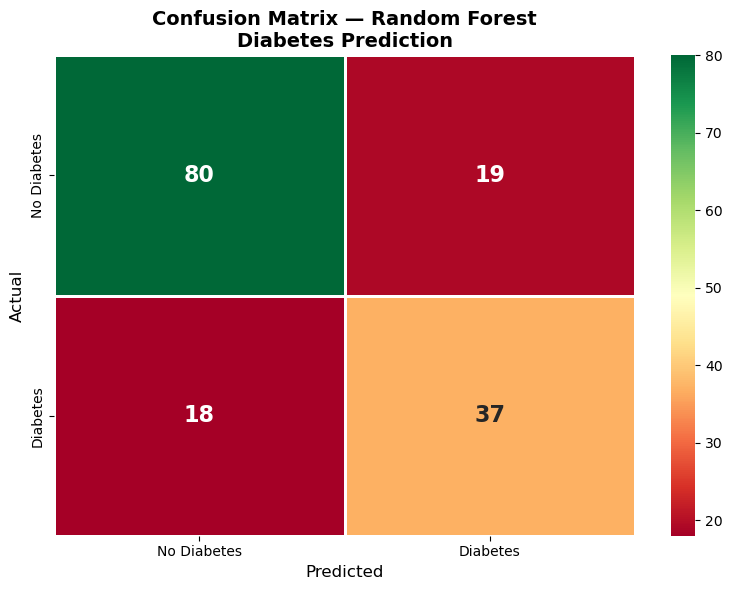

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})

plt.title('Confusion Matrix — Random Forest\nDiabetes Prediction',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/diabetes_rf_confusion_matrix.png', dpi=150)
plt.show()

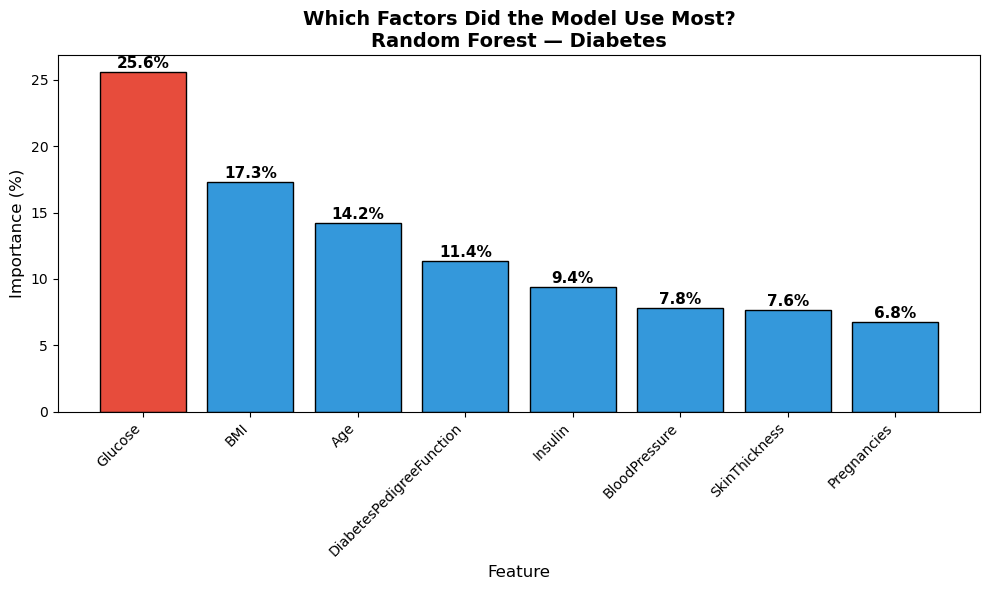

In [6]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#E74C3C' if i == 0 else '#3498DB' 
          for i in range(len(feature_importance))]

bars = plt.bar(feature_importance.index, 
               feature_importance.values * 100,
               color=colors, edgecolor='black')

for bar, val in zip(bars, feature_importance.values * 100):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             fontsize=11, fontweight='bold')

plt.title('Which Factors Did the Model Use Most?\nRandom Forest — Diabetes',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../plots/diabetes_rf_feature_importance.png', dpi=150)
plt.show()

In [9]:
import pickle

# Save the model
with open('../models/diabetes_rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")

Model saved successfully!


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")
print("X_train shape:", X_train_scaled.shape)

Data scaled successfully!
X_train shape: (614, 8)


In [11]:
# Build Neural Network
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model_nn.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Train
history = model_nn.fit(X_train_scaled, y_train,
                       epochs=100,
                       batch_size=32,
                       validation_split=0.2,
                       verbose=1)

print("Training complete!")

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6456 - loss: 0.6460 - val_accuracy: 0.6179 - val_loss: 0.6121
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6640 - loss: 0.5989 - val_accuracy: 0.6748 - val_loss: 0.5617
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7026 - loss: 0.5451 - val_accuracy: 0.7561 - val_loss: 0.5193
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7210 - loss: 0.5257 - val_accuracy: 0.7642 - val_loss: 0.4879
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7251 - loss: 0.5126 - val_accuracy: 0.7724 - val_loss: 0.4703
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7576 - loss: 0.4883 - val_accuracy: 0.7805 - val_loss: 0.4621
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7515 - loss: 0.4877 - val_accuracy: 0.7805 - val_loss: 0.4529
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7475 - loss: 0.4785 - val_accuracy: 0.

In [12]:
y_pred_nn = (model_nn.predict(X_test_scaled) > 0.5).astype(int)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_nn) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn,
      target_names=['No Diabetes', 'Diabetes']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 
Test Accuracy: 70.13%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.75      0.76        99
    Diabetes       0.58      0.62      0.60        55

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



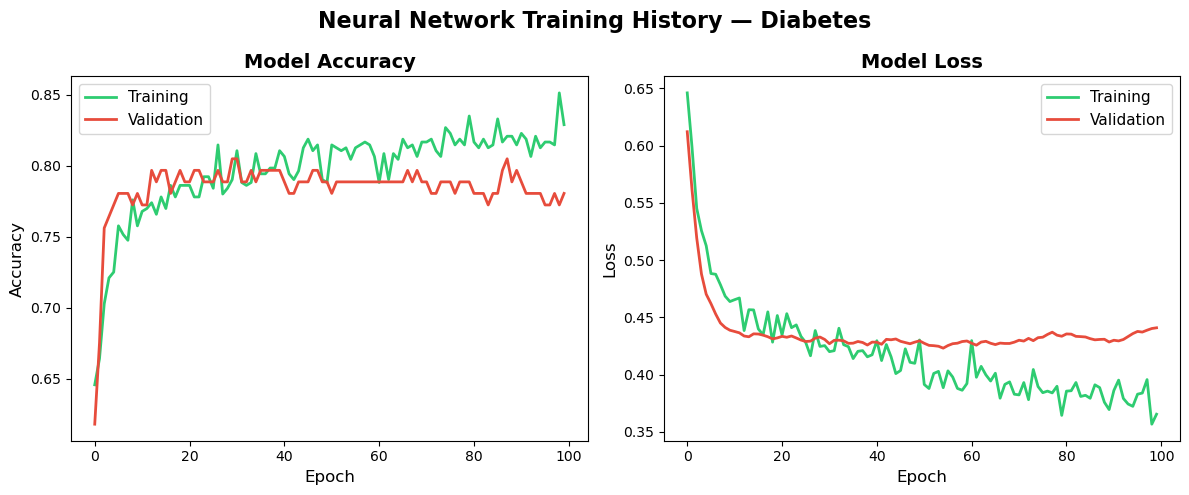

In [13]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 
         color='#2ECC71', linewidth=2, label='Training')
plt.plot(history.history['val_accuracy'], 
         color='#E74C3C', linewidth=2, label='Validation')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 
         color='#2ECC71', linewidth=2, label='Training')
plt.plot(history.history['val_loss'], 
         color='#E74C3C', linewidth=2, label='Validation')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)

plt.suptitle('Neural Network Training History — Diabetes',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/diabetes_nn_history.png', dpi=150)
plt.show()

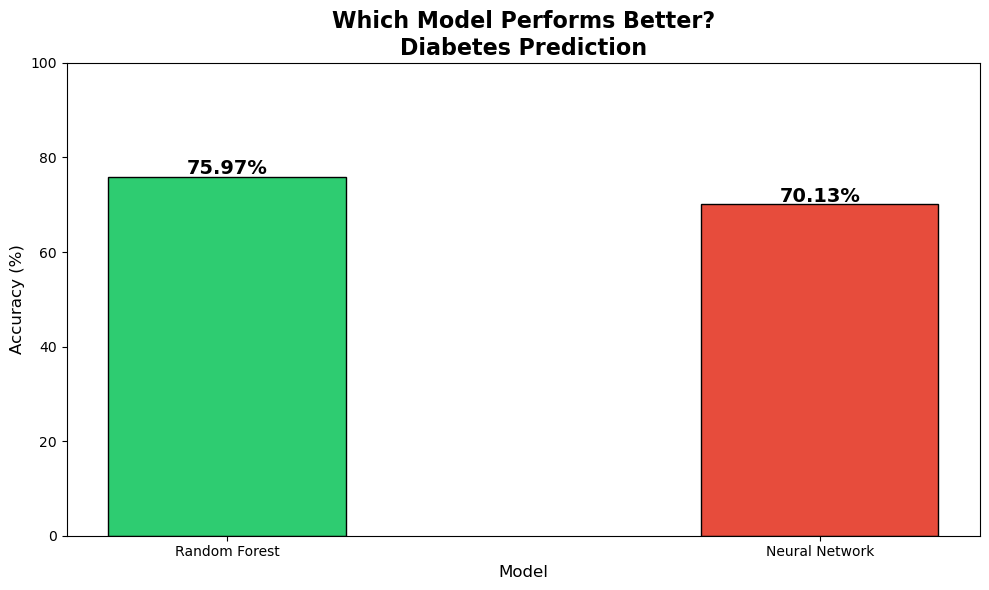

In [14]:
plt.figure(figsize=(10, 6))

models = ['Random Forest', 'Neural Network']
accuracies = [75.97, 70.13]
colors = ['#2ECC71', '#E74C3C']

bars = plt.bar(models, accuracies,
               color=colors, edgecolor='black', width=0.4)

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center',
             fontsize=14, fontweight='bold')

plt.title('Which Model Performs Better?\nDiabetes Prediction',
          fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('../plots/diabetes_model_comparison.png', dpi=150)
plt.show()

In [4]:
import sys
!{sys.executable} -m pip install xgboost

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

df_clean = pd.read_csv('../data/diabetes_clean.csv')

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Ready! Training samples:", X_train.shape[0])

Ready! Training samples: 614


In [6]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=2,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No Diabetes', 'Diabetes']))

XGBoost Accuracy: 72.08%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.83      0.71      0.77        99
    Diabetes       0.59      0.75      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.74      0.72      0.73       154



In [7]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"Healthy: {sum(y_train==0)} | Diabetic: {sum(y_train==1)}")

print("\nAfter SMOTE:")
print(f"Healthy: {sum(y_train_smote==0)} | Diabetic: {sum(y_train_smote==1)}")

Before SMOTE:
Healthy: 401 | Diabetic: 213

After SMOTE:
Healthy: 401 | Diabetic: 401


In [13]:
xgb_model_smote = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = xgb_model_smote.predict(X_test)

print(f"XGBoost + SMOTE Accuracy: {accuracy_score(y_test, y_pred_smote) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote,
      target_names=['No Diabetes', 'Diabetes']))

XGBoost + SMOTE Accuracy: 72.73%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.71      0.77        99
    Diabetes       0.59      0.76      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.73       154



In [14]:
from sklearn.model_selection import GridSearchCV

# Define parameters to test
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Grid Search
grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}
Best Score: 0.8929629629629631


In [15]:
best_xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=300,
    subsample=1.0,
    random_state=42,
    eval_metric='logloss'
)

best_xgb.fit(X_train_smote, y_train_smote)

y_pred_best = best_xgb.predict(X_test)

print(f"Tuned XGBoost Accuracy: {accuracy_score(y_test, y_pred_best) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=['No Diabetes', 'Diabetes']))

Tuned XGBoost Accuracy: 71.43%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.82      0.71      0.76        99
    Diabetes       0.58      0.73      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.72       154



In [16]:
params = {
    'n_estimators': [300, 400, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

grid_search2 = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search2.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search2.best_params_)
print("Best Score:", grid_search2.best_score_)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 1.0}
Best Score: 0.8929629629629631


In [8]:
import pickle
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Retrain XGBoost
xgb_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)
xgb_final.fit(X_train_smote, y_train_smote)

# Save
with open('../models/diabetes_xgb_final.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)

print("XGBoost model saved!")

XGBoost model saved!
